# IndoBERT with Augmented Data

## Data Loading and Preparation

Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re
import random
import tensorflow as tf
from transformers import (
    AutoTokenizer,
    TFBertForSequenceClassification,
    create_optimizer
)
from transformers import create_optimizer
from tf_keras.callbacks import EarlyStopping
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
import time

In [3]:
df = pd.read_csv('/kaggle/input/toxic-comments/Concated Data Cut.csv')
df.head()

,Comments,Final Label
0,Orang seperti ini biasa nya di kasih seneng du...,Provokasi
1,"Review nasi goreng ca dong, dulu sih mangkal d...",Provokasi
2,🤣🤣senggol bib gass..kasih paham😁,Non-Negatif
3,"ada harga 20k kmrn ada yg post, tapi lupa dima...",Non-Negatif
4,nanti kalo dah dewasa banget pengen ke msbreew...,Pornografi


Observe initial values

In [3]:
df['Final Label'].value_counts()

Final Label
Non-Negatif             8795
Provokasi               5302
Penghinaan              1135
Pornografi              1014
Negatif Lainnya          609
SARA                     511
Pencemaran Nama Baik     158
Name: count, dtype: int64

In [4]:
df.isna().sum()

Comments       0
Final Label    0
dtype: int64

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17524 entries, 0 to 17523
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Comments     17524 non-null  object
 1   Final Label  17524 non-null  object
dtypes: object(2)
memory usage: 273.9+ KB


## Data Preprocessing

In [4]:
new_df = df.copy()

### Cleansing

In [5]:
def cleansing(df):
    df_clean = df.str.lower()
    df_clean = [re.sub(r"\d+", "", i) for i in df_clean] # Numbers
    df_clean = [re.sub(r'http[s]?://\S+|www\.\S+', '', i) for i in df_clean] # URLs
    df_clean = [re.sub(r'@\S+', '', i) for i in df_clean]  # Mentions
    df_clean = [re.sub(r'\s+', ' ', i) for i in df_clean]  # Extra Spaces
    df_clean = [re.sub(r'(.)\1{2,}', r'\1\1', i) for i in df_clean]
    return df_clean

In [6]:
new_df['clean_text'] = cleansing(new_df['Comments'])
new_df.head(10)

,Comments,Final Label,clean_text
0,Orang seperti ini biasa nya di kasih seneng du...,Provokasi,orang seperti ini biasa nya di kasih seneng du...
1,"Review nasi goreng ca dong, dulu sih mangkal d...",Provokasi,"review nasi goreng ca dong, dulu sih mangkal d..."
2,🤣🤣senggol bib gass..kasih paham😁,Non-Negatif,🤣🤣senggol bib gass..kasih paham😁
3,"ada harga 20k kmrn ada yg post, tapi lupa dima...",Non-Negatif,"ada harga k kmrn ada yg post, tapi lupa dimana..."
4,nanti kalo dah dewasa banget pengen ke msbreew...,Pornografi,nanti kalo dah dewasa banget pengen ke msbreew...
5,d atas vt nyai resmi ditahan gak gak terima gue,Non-Negatif,d atas vt nyai resmi ditahan gak gak terima gue
6,Selamat lebaran om ded yang lain bisa di mmfin...,Provokasi,selamat lebaran om ded yang lain bisa di mmfin...
7,😂,Provokasi,😂
8,aq team nikita mirzani,Non-Negatif,aq team nikita mirzani
9,😂😂😂 gue suka gaya loe amiiiiiiii🔥🔥🔥,Non-Negatif,😂😂 gue suka gaya loe amii🔥🔥


### WordClouds

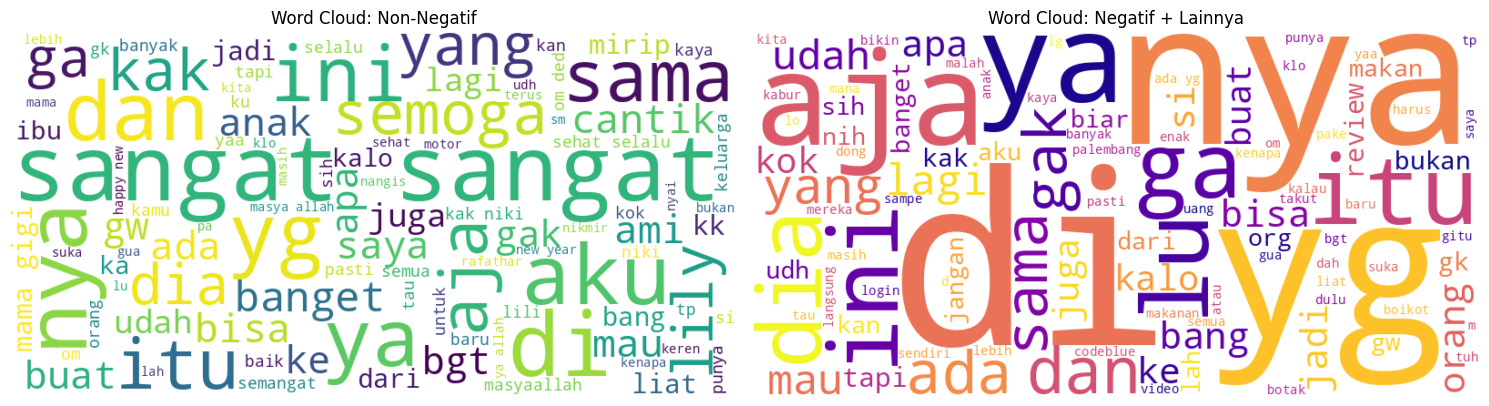

In [11]:
# 1. Filter data untuk label 'Non-Negatif'
non_negatif_data = new_df[new_df['Final Label'] == 'Non-Negatif']

# 2. Gabungkan teks-teks untuk label 'Non-Negatif'
non_negatif_text = " ".join(non_negatif_data['clean_text'])

# 3. Filter data untuk label selain 'Non-Negatif' (Misalnya untuk 'Negatif' dan label lainnya)
negatif_data = new_df[new_df['Final Label'] != 'Non-Negatif']

# 4. Gabungkan teks-teks untuk label selain 'Non-Negatif'
negatif_text = " ".join(negatif_data['clean_text'])

# 5. Word Cloud untuk label 'Non-Negatif'
wordcloud_non_negatif = WordCloud(width=800, height=400, background_color="white", colormap="viridis",
                                   max_words=100, contour_width=3, contour_color="steelblue").generate(non_negatif_text)

# 6. Word Cloud untuk label selain 'Non-Negatif' (Negatif + Lainnya)
wordcloud_negatif = WordCloud(width=800, height=400, background_color="white", colormap="plasma",
                              max_words=100, contour_width=3, contour_color="steelblue").generate(negatif_text)

# 7. Tampilkan kedua Word Cloud
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Tampilkan Word Cloud untuk Non-Negatif
axes[0].imshow(wordcloud_non_negatif, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Word Cloud: Non-Negatif")

# Tampilkan Word Cloud untuk label selain Non-Negatif
axes[1].imshow(wordcloud_negatif, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Word Cloud: Negatif + Lainnya")

plt.tight_layout()
plt.show()

Needs abbreviation handling: 'kk', 'yg', 'udh', 'gw', 'tp','gk', 'lg', 'sm', 'klo','org',

### Abbreviation Handling

In [7]:
abbr_dict = {
    "gk":"ga",
    "gx":"ga",
    "nggak":"ga",
    "gak":"ga",
    "kk":"kakak",
    "yg":"yang",
    "udh":"sudah",
    "udah":"sudah",
    "gw":"gue",
    "lo":"lu",
    "tp":"tapi",
    "lg":"lagi",
    "sm":"sama",
    "klo":"kalau",
    "klw":"kalau",
    "kalo":"kalau",
    "org":"orang",
    "w":"gue",
    "ku":"aku",
    "bru":"baru",
    "bgt":"banget",
    "si":"sih",
    "knp":"kenapa",
    "ato":"atau",
    "ky":"kaya",
    "bgst":"bangsat",
    "ajg":"anjing",
    "bg":"bang",
    "smg":"semoga"
}


In [8]:
def normalize_abbr(text, abbr_dict):
    pattern = r'\b(' + '|'.join(map(re.escape, abbr_dict.keys())) + r')\b'
    return re.sub(pattern, lambda x: abbr_dict[x.group()], text)
    
def expand_repetition_notation(text):
    # Handle Unicode superscripts (², ³, etc.)
    # Convert ² to -repetition
    text = re.sub(r'(\w+)²', r'\1-\1', text)
    text = re.sub(r'(\w+)³', r'\1-\1-\1', text)
    
    # Handle word^digit (e.g., kata^2, org^3)
    text = re.sub(r'(\w+)\^(\d+)', r'\1-\1', text)
    
    # Handle word^word (sometimes people write kata^kata)
    text = re.sub(r'(\w+)\^\1', r'\1-\1', text)
    
    # Handle word2 at word boundaries (more conservative)
    text = re.sub(r'\b([a-z]{3,})2\b', r'\1-\1', text, flags=re.IGNORECASE)
    return text

def normalize_text(text):
    text = normalize_abbr(text,abbr_dict)
    text = expand_repetition_notation(text)
    return text

In [9]:
new_df['normalized_text'] = new_df['clean_text'].apply(normalize_text)
new_df

,Comments,Final Label,clean_text,normalized_text
0,Orang seperti ini biasa nya di kasih seneng du...,Provokasi,orang seperti ini biasa nya di kasih seneng du...,orang seperti ini biasa nya di kasih seneng du...
1,"Review nasi goreng ca dong, dulu sih mangkal d...",Provokasi,"review nasi goreng ca dong, dulu sih mangkal d...","review nasi goreng ca dong, dulu sih mangkal d..."
2,🤣🤣senggol bib gass..kasih paham😁,Non-Negatif,🤣🤣senggol bib gass..kasih paham😁,🤣🤣senggol bib gass..kasih paham😁
3,"ada harga 20k kmrn ada yg post, tapi lupa dima...",Non-Negatif,"ada harga k kmrn ada yg post, tapi lupa dimana...","ada harga k kmrn ada yang post, tapi lupa dima..."
4,nanti kalo dah dewasa banget pengen ke msbreew...,Pornografi,nanti kalo dah dewasa banget pengen ke msbreew...,nanti kalau dah dewasa banget pengen ke msbree...
...,...,...,...,...
17519,haha kemarin ada yang prediksi bakal bagi-bagi...,Provokasi,haha kemarin ada yang prediksi bakal bagi-bagi...,haha kemarin ada yang prediksi bakal bagi-bagi...
17520,smg lebaran pakai baju oranye,Provokasi,smg lebaran pakai baju oranye,semoga lebaran pakai baju oranye
17521,"yang Pro kak nikita, rata² orang² jujur yang s...",Non-Negatif,"yang pro kak nikita, rata² orang² jujur yang s...","yang pro kak nikita, rata-rata orang-orang juj..."
17522,mama gigi cantik bgt,Non-Negatif,mama gigi cantik bgt,mama gigi cantik banget


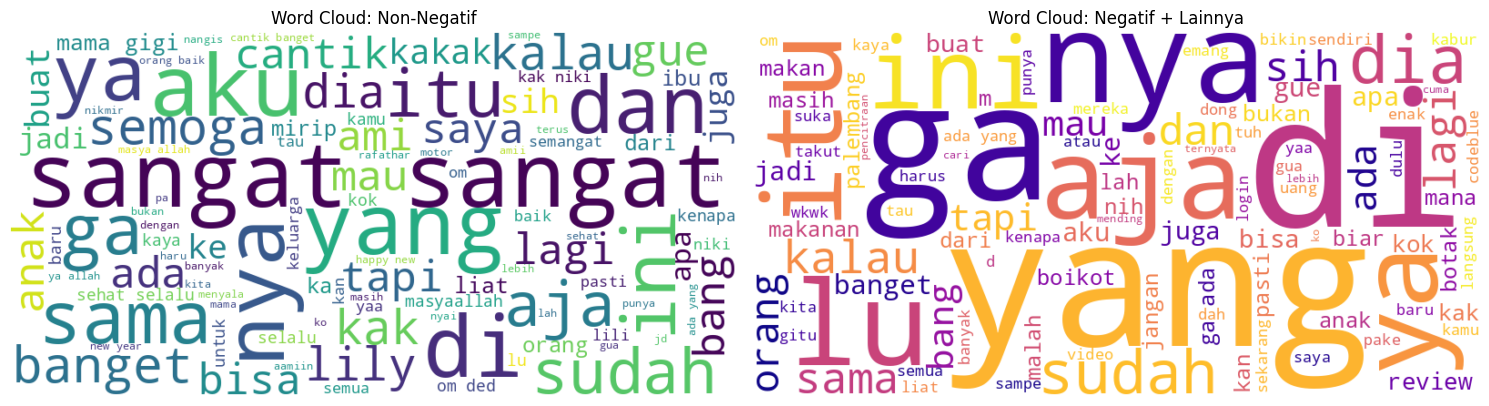

In [10]:
# 1. Filter data untuk label 'Non-Negatif'
non_negatif_data = new_df[new_df['Final Label'] == 'Non-Negatif']

# 2. Gabungkan teks-teks untuk label 'Non-Negatif'
non_negatif_text = " ".join(non_negatif_data['normalized_text'])

# 3. Filter data untuk label selain 'Non-Negatif' (Misalnya untuk 'Negatif' dan label lainnya)
negatif_data = new_df[new_df['Final Label'] != 'Non-Negatif']

# 4. Gabungkan teks-teks untuk label selain 'Non-Negatif'
negatif_text = " ".join(negatif_data['normalized_text'])

# 5. Word Cloud untuk label 'Non-Negatif'
wordcloud_non_negatif = WordCloud(width=800, height=400, background_color="white", colormap="viridis",
                                   max_words=100, contour_width=3, contour_color="steelblue").generate(non_negatif_text)

# 6. Word Cloud untuk label selain 'Non-Negatif' (Negatif + Lainnya)
wordcloud_negatif = WordCloud(width=800, height=400, background_color="white", colormap="plasma",
                              max_words=100, contour_width=3, contour_color="steelblue").generate(negatif_text)

# 7. Tampilkan kedua Word Cloud
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

# Tampilkan Word Cloud untuk Non-Negatif
axes[0].imshow(wordcloud_non_negatif, interpolation="bilinear")
axes[0].axis("off")
axes[0].set_title("Word Cloud: Non-Negatif")

# Tampilkan Word Cloud untuk label selain Non-Negatif
axes[1].imshow(wordcloud_negatif, interpolation="bilinear")
axes[1].axis("off")
axes[1].set_title("Word Cloud: Negatif + Lainnya")

plt.tight_layout()
plt.show()

### Label Preparation

Encoding text labels into numbers

In [10]:
toxic_labels = ['Pornografi', 'Pencemaran Nama Baik', 'Provokasi', 'SARA', 'Penghinaan', 'Negatif Lainnya']
all_labels = toxic_labels + ['Non-Negatif']

# Mapper - label to int
label2id = {name: i for i, name in enumerate(all_labels)}
new_df["label_id"] = new_df["Final Label"].map(label2id)
new_df["label_stage1"] = new_df["Final Label"].apply(lambda x: 0 if x == 'Non-Negatif' else 1)

# IDs 0-5 for the 6 toxic labels
label2id_s2 = {name: i for i, name in enumerate(toxic_labels)}
# Labels for stage 2. -1 for Non-Negatif
new_df["label_stage2"] = new_df["Final Label"].map(label2id_s2).fillna(-1).astype(int)

In [11]:
new_df["augmented"] = False

In [12]:
new_df

,Comments,Final Label,clean_text,normalized_text,label_id,label_stage1,label_stage2,augmented
0,Orang seperti ini biasa nya di kasih seneng du...,Provokasi,orang seperti ini biasa nya di kasih seneng du...,orang seperti ini biasa nya di kasih seneng du...,2,1,2,False
1,"Review nasi goreng ca dong, dulu sih mangkal d...",Provokasi,"review nasi goreng ca dong, dulu sih mangkal d...","review nasi goreng ca dong, dulu sih mangkal d...",2,1,2,False
2,🤣🤣senggol bib gass..kasih paham😁,Non-Negatif,🤣🤣senggol bib gass..kasih paham😁,🤣🤣senggol bib gass..kasih paham😁,6,0,-1,False
3,"ada harga 20k kmrn ada yg post, tapi lupa dima...",Non-Negatif,"ada harga k kmrn ada yg post, tapi lupa dimana...","ada harga k kmrn ada yang post, tapi lupa dima...",6,0,-1,False
4,nanti kalo dah dewasa banget pengen ke msbreew...,Pornografi,nanti kalo dah dewasa banget pengen ke msbreew...,nanti kalau dah dewasa banget pengen ke msbree...,0,1,0,False
...,...,...,...,...,...,...,...,...
17519,haha kemarin ada yang prediksi bakal bagi-bagi...,Provokasi,haha kemarin ada yang prediksi bakal bagi-bagi...,haha kemarin ada yang prediksi bakal bagi-bagi...,2,1,2,False
17520,smg lebaran pakai baju oranye,Provokasi,smg lebaran pakai baju oranye,semoga lebaran pakai baju oranye,2,1,2,False
17521,"yang Pro kak nikita, rata² orang² jujur yang s...",Non-Negatif,"yang pro kak nikita, rata² orang² jujur yang s...","yang pro kak nikita, rata-rata orang-orang juj...",6,0,-1,False
17522,mama gigi cantik bgt,Non-Negatif,mama gigi cantik bgt,mama gigi cantik banget,6,0,-1,False


In [13]:
new_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17524 entries, 0 to 17523
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Comments         17524 non-null  object
 1   Final Label      17524 non-null  object
 2   clean_text       17524 non-null  object
 3   normalized_text  17524 non-null  object
 4   label_id         17524 non-null  int64 
 5   label_stage1     17524 non-null  int64 
 6   label_stage2     17524 non-null  int64 
 7   augmented        17524 non-null  bool  
dtypes: bool(1), int64(3), object(4)
memory usage: 975.6+ KB


In [14]:
augment_prep_df = new_df.copy()
augment_prep_df = augment_prep_df.drop(['clean_text'],axis=1)

## Data Split

In [15]:
train_df, temp_df = train_test_split(
    new_df,
    test_size=0.2,
    random_state=42,
    stratify=new_df["Final Label"]
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["Final Label"]
)

train_texts_s1, y_train_s1 = train_df["normalized_text"].tolist(), train_df["label_stage1"].values
val_texts_s1, y_val_s1 = val_df["normalized_text"].tolist(), val_df["label_stage1"].values
test_texts_s1, y_test_s1 = test_df["normalized_text"].tolist(), test_df["label_stage1"].values

train_df_s2 = train_df[train_df["label_stage1"] == 1]
val_df_s2 = val_df[val_df["label_stage1"] == 1]
test_df_s2 = test_df[test_df["label_stage1"] == 1]

train_texts_s2, y_train_s2 = train_df_s2["normalized_text"].tolist(), train_df_s2["label_stage2"].values
val_texts_s2, y_val_s2 = val_df_s2["normalized_text"].tolist(), val_df_s2["label_stage2"].values
test_texts_s2, y_test_s2 = test_df_s2["normalized_text"].tolist(), test_df_s2["label_stage2"].values

print(f"\nStage 1 - Train: {len(y_train_s1)}, Val: {len(y_val_s1)}, Test: {len(y_test_s1)}")
print(f"Stage 2 - Train: {len(y_train_s2)}, Val: {len(y_val_s2)}, Test: {len(y_test_s2)}")


Stage 1 - Train: 14019, Val: 1752, Test: 1753
Stage 2 - Train: 6983, Val: 873, Test: 873


In [16]:
slice1 = test_df[test_df['augmented']==True]
print(f"{len(slice1)}")

0


## Data Augmentation

In [116]:
from transformers import MarianMTModel, MarianTokenizer
import torch

# Indonesian → English
id_en_model_name = "Helsinki-NLP/opus-mt-id-en"
id_en_tokenizer = MarianTokenizer.from_pretrained(id_en_model_name)
id_en_model = MarianMTModel.from_pretrained(id_en_model_name)

# English → Indonesian
en_id_model_name = "Helsinki-NLP/opus-mt-en-id"
en_id_tokenizer = MarianTokenizer.from_pretrained(en_id_model_name)
en_id_model = MarianMTModel.from_pretrained(en_id_model_name)

/usr/local/lib/python3.12/dist-packages/transformers/models/marian/tokenization_marian.py:175: UserWarning: Recommended: pip install sacremoses.
  warnings.warn("Recommended: pip install sacremoses.")


In [117]:
# def back_translate(text, max_length=128):
#     # ID → EN
#     id_inputs = id_en_tokenizer(
#         text, return_tensors="pt", truncation=True, max_length=max_length
#     )
#     with torch.no_grad():
#         en_outputs = id_en_model.generate(**id_inputs)
#     en_text = id_en_tokenizer.decode(en_outputs[0], skip_special_tokens=True)

#     # EN → ID
#     en_inputs = en_id_tokenizer(
#         en_text, return_tensors="pt", truncation=True, max_length=max_length
#     )
#     with torch.no_grad():
#         id_outputs = en_id_model.generate(**en_inputs)
#     id_text = en_id_tokenizer.decode(id_outputs[0], skip_special_tokens=True)

#     return id_text

In [118]:
# augmented_rows = []

# for label in minority_classes:
#     subset = train_df_s2[train_df_s2["label_stage2"] == label]
#     for _, row in subset.iterrows():
#         original = row["clean_text"]
#         try:
#             augmented = back_translate(original)
#             if augmented.lower() != original.lower() and len(augmented.split()) >= 2:
#                 augmented_rows.append({
#                     "clean_text": augmented,
#                     "label_stage2": label,
#                     "label_stage1": 1,
#                     "augmented": True
#                 })
#         except Exception:
#             continue

## Loading Augmented Data

In [17]:
augmented_df = pd.read_csv('/kaggle/input/toxic-comments/augmented.csv')
augmented_df.head(10)

,clean_text,label_stage2,label_stage1,augmented
0,PERDAMAIAN GRAGAS,4,1,True
1,hama codeblue,4,1,True
2,"Makan sepanjang waktu, seperti Ooops.",4,1,True
3,"Persetan denganmu, bung.",4,1,True
4,HAMA PAIN TEMPLE,4,1,True
5,Jangan coba lagi makanan pridavan-mu.,4,1,True
6,▪ Guru Razman kah ▪,4,1,True
7,Apa yang salah dengan ytim?,4,1,True
8,♪ Boti boxing ♪,4,1,True
9,Squidward tampan dan Squidward cantik,4,1,True


### Combining augmented and initial data

In [18]:
id2label_s2 = {i: name for i, name in enumerate(toxic_labels)}

In [19]:
augmented_df["Final Label"] = augmented_df["label_stage2"].map(id2label_s2)
augmented_df["label_id"] = augmented_df["Final Label"].map(label2id)
augmented_df["Comments"] = augmented_df["clean_text"]
final_columns = [
    "Comments",
    "Final Label",
    "clean_text",
    "label_id",
    "label_stage1",
    "label_stage2",
    "augmented"
]

augmented_df = augmented_df[final_columns]

In [20]:
augmented_df['normalized_text'] = augmented_df['clean_text'].apply(normalize_text)
augmented_df

,Comments,Final Label,clean_text,label_id,label_stage1,label_stage2,augmented,normalized_text
0,PERDAMAIAN GRAGAS,Penghinaan,PERDAMAIAN GRAGAS,4,1,4,True,PERDAMAIAN GRAGAS
1,hama codeblue,Penghinaan,hama codeblue,4,1,4,True,hama codeblue
2,"Makan sepanjang waktu, seperti Ooops.",Penghinaan,"Makan sepanjang waktu, seperti Ooops.",4,1,4,True,"Makan sepanjang waktu, seperti Ooops."
3,"Persetan denganmu, bung.",Penghinaan,"Persetan denganmu, bung.",4,1,4,True,"Persetan denganmu, bung."
4,HAMA PAIN TEMPLE,Penghinaan,HAMA PAIN TEMPLE,4,1,4,True,HAMA PAIN TEMPLE
...,...,...,...,...,...,...,...,...
2310,Wajah membenci Tuhan.,Pencemaran Nama Baik,Wajah membenci Tuhan.,1,1,1,True,Wajah membenci Tuhan.
2311,Ingin melihat orang ini masuk untuk tahun ini.,Pencemaran Nama Baik,Ingin melihat orang ini masuk untuk tahun ini.,1,1,1,True,Ingin melihat orang ini masuk untuk tahun ini.
2312,Ini bukan untuk apa-apa untuk menjilat.,Pencemaran Nama Baik,Ini bukan untuk apa-apa untuk menjilat.,1,1,1,True,Ini bukan untuk apa-apa untuk menjilat.
2313,Semuanya tipuan dari awal tipuan willie juga s...,Pencemaran Nama Baik,Semuanya tipuan dari awal tipuan willie juga s...,1,1,1,True,Semuanya tipuan dari awal tipuan willie juga s...


In [21]:
combined_df = pd.concat(
    [train_df, augmented_df],
    axis=0,
    ignore_index=True
)

In [22]:
combined_df

,Comments,Final Label,clean_text,normalized_text,label_id,label_stage1,label_stage2,augmented
0,Cina,SARA,cina,cina,3,1,3,False
1,lbh cantik agnes yg dulu sih,Non-Negatif,lbh cantik agnes yg dulu sih,lbh cantik agnes yang dulu sih,6,0,-1,False
2,"Ridho seorang ibu adalah segalanya,tetap seman...",Non-Negatif,"ridho seorang ibu adalah segalanya,tetap seman...","ridho seorang ibu adalah segalanya,tetap seman...",6,0,-1,False
3,Aku Marasa sana sama Aya aku😭😭😭😭😢,Non-Negatif,aku marasa sana sama aya aku😭😭😢,aku marasa sana sama aya aku😭😭😢,6,0,-1,False
4,"Niki mahh vibes'y sll pOsitif ,biarpUN amarah'...",Negatif Lainnya,"niki mahh vibes'y sll positif ,biarpun amarah'...","niki mahh vibes'y sll positif ,biarpun amarah'...",5,1,5,False
...,...,...,...,...,...,...,...,...
16329,Wajah membenci Tuhan.,Pencemaran Nama Baik,Wajah membenci Tuhan.,Wajah membenci Tuhan.,1,1,1,True
16330,Ingin melihat orang ini masuk untuk tahun ini.,Pencemaran Nama Baik,Ingin melihat orang ini masuk untuk tahun ini.,Ingin melihat orang ini masuk untuk tahun ini.,1,1,1,True
16331,Ini bukan untuk apa-apa untuk menjilat.,Pencemaran Nama Baik,Ini bukan untuk apa-apa untuk menjilat.,Ini bukan untuk apa-apa untuk menjilat.,1,1,1,True
16332,Semuanya tipuan dari awal tipuan willie juga s...,Pencemaran Nama Baik,Semuanya tipuan dari awal tipuan willie juga s...,Semuanya tipuan dari awal tipuan willie juga s...,1,1,1,True


In [80]:
print(combined_df["augmented"].value_counts())
print(combined_df["label_stage1"].value_counts())
print(combined_df["label_stage2"].value_counts())
print(combined_df.isnull().sum())

augmented
False    14019
True      2315
Name: count, dtype: int64
label_stage1
1    9298
0    7036
Name: count, dtype: int64
label_stage2
-1    7036
 2    4242
 4    1657
 0    1478
 5     892
 3     782
 1     247
Name: count, dtype: int64
Comments           0
Final Label        0
clean_text         0
normalized_text    0
label_id           0
label_stage1       0
label_stage2       0
augmented          0
dtype: int64


In [44]:
train_texts_s1, y_train_s1 = combined_df["normalized_text"].tolist(), combined_df["label_stage1"].values
train_df_s2 = combined_df[combined_df["label_stage1"] == 1]
train_texts_s2, y_train_s2 = train_df_s2["normalized_text"].tolist(), train_df_s2["label_stage2"].values

print(f"\nStage 1 - Train: {len(y_train_s1)}, Val: {len(y_val_s1)}, Test: {len(y_test_s1)}")
print(f"Stage 2 - Train: {len(y_train_s2)}, Val: {len(y_val_s2)}, Test: {len(y_test_s2)}")


Stage 1 - Train: 16334, Val: 1752, Test: 1753
Stage 2 - Train: 9298, Val: 873, Test: 873


## IndoBERT 2-Stage

### Creating Datasets

Preparing data for IndoBERT input

In [30]:
model_name = "indobenchmark/indobert-base-p2"

tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(texts):
    return tokenizer(
        texts, truncation=True, padding=True, max_length=128, return_tensors="tf"
    )

enc_train_s1, enc_val_s1, enc_test_s1 = tokenize(train_texts_s1), tokenize(val_texts_s1), tokenize(test_texts_s1)
enc_train_s2, enc_val_s2, enc_test_s2 = tokenize(train_texts_s2), tokenize(val_texts_s2), tokenize(test_texts_s2)

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.


In [104]:
batch_size = 16

# Stage 1
train_ds_s1 = tf.data.Dataset.from_tensor_slices((dict(enc_train_s1), y_train_s1.astype('int32'))).shuffle(len(y_train_s1)).batch(batch_size)
val_ds_s1   = tf.data.Dataset.from_tensor_slices((dict(enc_val_s1), y_val_s1.astype('int32'))).batch(batch_size)
test_ds_s1  = tf.data.Dataset.from_tensor_slices((dict(enc_test_s1), y_test_s1.astype('int32'))).batch(batch_size)

# Stage 2
train_ds_s2 = tf.data.Dataset.from_tensor_slices((dict(enc_train_s2), y_train_s2.astype('int32'))).shuffle(len(y_train_s2)).batch(batch_size)
val_ds_s2   = tf.data.Dataset.from_tensor_slices((dict(enc_val_s2), y_val_s2.astype('int32'))).batch(batch_size)
test_ds_s2  = tf.data.Dataset.from_tensor_slices((dict(enc_test_s2), y_test_s2.astype('int32'))).batch(batch_size)

In [105]:
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_s1),
    y=y_train_s1
)

weights_s2 = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_s2),
    y=y_train_s2
)

class_weights_s1 = {i: weights[i] for i in range(len(weights))}
class_weights_s2 = {i: weights_s2[i] for i in range(len(weights_s2))}

print("New Calculated Class Weights for Stage 1:")
print(class_weights_s1, "\n")
print(class_weights_s2)

New Calculated Class Weights for Stage 1:
{0: np.float64(1.1607447413303014), 1: np.float64(0.8783609378360938)} 

{0: np.float64(1.048488949030221), 1: np.float64(6.273954116059379), 2: np.float64(0.3653151029388653), 3: np.float64(1.9816709292412618), 4: np.float64(0.9352243009454838), 5: np.float64(1.7372944693572496)}


## IndoBERT 2-Stage Default

### Training

#### Early Stopping

In [38]:
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True,
    verbose=1
)

#### Model (Default)

In [20]:
model_default = TFBertForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p2",
    num_labels=2
)

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=2e-5,
    epsilon=1e-8,
    weight_decay=0.0
)

model_default.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

tf_model.h5:   0%|          | 0.00/656M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p2 and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [21]:
model_default_s2 = TFBertForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p2", num_labels=len(toxic_labels)
)
optimizer = tf.keras.optimizers.AdamW(
    learning_rate=2e-5,
    epsilon=1e-8,
    weight_decay=0.0 
)
model_default_s2.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p2 and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [19]:
epochs = 10

In [52]:
history_default = model_default.fit(
    train_ds_s1,
    validation_data=val_ds_s1,
    epochs=epochs,
    callbacks=[early_stopping],
    class_weight=class_weights_s1
)

Epoch 1/10
877/877 [==============================] - 393s 448ms/step - loss: 0.2553 - accuracy: 0.8969 - val_loss: 0.3677 - val_accuracy: 0.8299
Epoch 2/10
877/877 [==============================] - 392s 447ms/step - loss: 0.1678 - accuracy: 0.9374 - val_loss: 0.4689 - val_accuracy: 0.8425
Epoch 3/10
877/877 [==============================] - 392s 447ms/step - loss: 0.1214 - accuracy: 0.9563 - val_loss: 0.5073 - val_accuracy: 0.8350
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


In [53]:
history_default_s2 = model_default_s2.fit(
    train_ds_s2,
    validation_data=val_ds_s2,
    epochs=epochs,
    callbacks=[early_stopping],
    class_weight=class_weights_s2
)

Epoch 1/10
437/437 [==============================] - 196s 449ms/step - loss: 0.3316 - accuracy: 0.8193 - val_loss: 1.1662 - val_accuracy: 0.6289
Epoch 2/10
437/437 [==============================] - 196s 448ms/step - loss: 0.2350 - accuracy: 0.8691 - val_loss: 1.2059 - val_accuracy: 0.6357
Epoch 3/10
437/437 [==============================] - 195s 447ms/step - loss: 0.2110 - accuracy: 0.8849 - val_loss: 1.2570 - val_accuracy: 0.6506
Epoch 3: early stopping
Restoring model weights from the end of the best epoch: 1.


#### 2-Stage Model Evaluation (Default)

In [54]:
# Stage 1
y_pred_s1 = tf.argmax(model_default.predict(test_ds_s1).logits, axis=1).numpy()
print("Stage 1 Report:\n", classification_report(y_test_s1, y_pred_s1, target_names=["Non Toxic", "Toxic"]))

# Stage 2
y_pred_s2 = tf.argmax(model_default_s2.predict(test_ds_s2).logits, axis=1).numpy()
print("Stage 2 Report:\n", classification_report(y_test_s2, y_pred_s2, target_names=toxic_labels))

110/110 [==============================] - 16s 147ms/step
Stage 1 Report:
               precision    recall  f1-score   support

   Non Toxic       0.86      0.82      0.84       880
       Toxic       0.82      0.86      0.84       873

    accuracy                           0.84      1753
   macro avg       0.84      0.84      0.84      1753
weighted avg       0.84      0.84      0.84      1753

55/55 [==============================] - 8s 146ms/step
Stage 2 Report:
                       precision    recall  f1-score   support

          Pornografi       0.57      0.85      0.68       101
Pencemaran Nama Baik       0.06      0.06      0.06        16
           Provokasi       0.88      0.65      0.75       530
                SARA       0.86      0.75      0.80        51
          Penghinaan       0.47      0.56      0.51       114
     Negatif Lainnya       0.18      0.39      0.24        61

            accuracy                           0.64       873
           macro avg       0

In [23]:
tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p2")

def batched_predict_stage1(texts, model, batch_size=16):
    preds = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]

        encodings = tokenizer(
            batch_texts,
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='tf'
        )

        logits = model(encodings, training=False).logits
        batch_preds = tf.argmax(logits, axis=1).numpy()
        preds.extend(batch_preds)

    return np.array(preds)


def predict_pipeline_batched(texts, model1, model2, batch_size=16):
    preds_s1 = batched_predict_stage1(texts, model1, batch_size)
    
    negative_indices = []
    negative_texts = []
    for i, pred_s1 in enumerate(preds_s1):
        if pred_s1 != 0:  # Negative
            negative_indices.append(i)
            negative_texts.append(texts[i])
    
    preds_s2_dict = {}
    for i in range(0, len(negative_texts), batch_size):
        batch_texts = negative_texts[i:i+batch_size]
        encodings = tokenizer(
            batch_texts,
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='tf'
        )
        logits = model2(encodings, training=False).logits
        batch_preds = tf.argmax(logits, axis=1).numpy()
        
        for j, orig_idx in enumerate(negative_indices[i:i+batch_size]):
            preds_s2_dict[orig_idx] = batch_preds[j]
    
    final_preds = []
    for i, pred_s1 in enumerate(preds_s1):
        if pred_s1 == 0:
            final_preds.append(label2id['Non-Negatif'])
        else:
            final_preds.append(preds_s2_dict[i])
    
    return np.array(final_preds)

In [58]:
final_preds = predict_pipeline(test_df["normalized_text"].tolist(), model_default, model_default_s2)

print("Combined 2-Stage Classification Report:\n")
print(classification_report(
    test_df["label_id"],
    final_preds,
    target_names=all_labels,
    zero_division=0
))

Combined 2-Stage Classification Report:

                      precision    recall  f1-score   support

          Pornografi       0.45      0.66      0.53       101
Pencemaran Nama Baik       0.05      0.06      0.06        16
           Provokasi       0.78      0.63      0.70       530
                SARA       0.72      0.65      0.68        51
          Penghinaan       0.44      0.51      0.47       114
     Negatif Lainnya       0.12      0.28      0.17        61
         Non-Negatif       0.86      0.82      0.84       880

            accuracy                           0.70      1753
           macro avg       0.49      0.51      0.49      1753
        weighted avg       0.75      0.70      0.72      1753



In [35]:
# warmup run before measuring
_ = predict_pipeline(
    test_df["clean_text"].tolist()[:32],
    model_default,
    model_default_s2
)

In [36]:
start_time = time.time()

final_preds = predict_pipeline(
    test_df["clean_text"].tolist(),
    model_default,
    model_default_s2
)

end_time = time.time()

total_time = end_time - start_time
num_samples = len(test_df)

print(f"Total inference time: {total_time:.4f} seconds")
print(f"Average time per sample: {total_time / num_samples:.6f} seconds")
print(f"Samples per second: {num_samples / total_time:.2f}")


Total inference time: 191.5082 seconds
Average time per sample: 0.109246 seconds
Samples per second: 9.15


In [24]:
tokenizer = AutoTokenizer.from_pretrained("indobenchmark/indobert-base-p2")

def batched_predict_stage1_probs(texts, model, batch_size=16):
    probs_all = []

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i:i+batch_size]

        encodings = tokenizer(
            batch_texts,
            truncation=True,
            padding='max_length',
            max_length=128,
            return_tensors='tf'
        )

        logits = model(encodings, training=False).logits
        probs = tf.nn.softmax(logits, axis=1).numpy()
        probs_all.extend(probs)

    return np.array(probs_all)

def predict_pipeline_full(texts, model1, model2, batch_size=16):
    probs_s1 = batched_predict_stage1_probs(texts, model1, batch_size)
    
    negative_mask = probs_s1[:, 1] > probs_s1[:, 0]  # prob_neg > prob_non_neg
    negative_indices = np.where(negative_mask)[0]
    negative_texts = [texts[i] for i in negative_indices]
    
    probs_s2_dict = {}
    if len(negative_texts) > 0:
        for i in range(0, len(negative_texts), batch_size):
            batch_texts = negative_texts[i:i+batch_size]
            encodings = tokenizer(
                batch_texts,
                truncation=True,
                padding='max_length',
                max_length=128,
                return_tensors='tf'
            )
            logits = model2(encodings, training=False).logits
            probs = tf.nn.softmax(logits, axis=1).numpy()
            
            for j, orig_idx in enumerate(negative_indices[i:i+batch_size]):
                probs_s2_dict[orig_idx] = probs[j]
    
    final_preds = np.zeros(len(texts), dtype=int)
    final_probs = np.zeros((len(texts), 7))
    
    for i in range(len(texts)):
        prob_non_neg = probs_s1[i][0]
        prob_neg = probs_s1[i][1]
        
        if not negative_mask[i]: 
            final_probs[i, 6] = 1.0
            final_preds[i] = 6
        else: 
            probs_s2 = probs_s2_dict[i]
            final_probs[i, 6] = prob_non_neg
            final_probs[i, 0:6] = prob_neg * probs_s2
            final_preds[i] = np.argmax(probs_s2)
    
    return final_preds, final_probs

In [73]:
y_pred, y_probs = predict_pipeline_full(test_df["normalized_text"].tolist(), model_default, model_default_s2)
print("Combined 2-Stage Classification Report:\n")
print(classification_report(test_df["label_id"], y_pred, target_names=all_labels))

Combined 2-Stage Classification Report:

                      precision    recall  f1-score   support

          Pornografi       0.45      0.66      0.53       101
Pencemaran Nama Baik       0.05      0.06      0.06        16
           Provokasi       0.78      0.63      0.70       530
                SARA       0.72      0.65      0.68        51
          Penghinaan       0.44      0.51      0.47       114
     Negatif Lainnya       0.12      0.28      0.17        61
         Non-Negatif       0.86      0.82      0.84       880

            accuracy                           0.70      1753
           macro avg       0.49      0.51      0.49      1753
        weighted avg       0.75      0.70      0.72      1753



In [74]:
final_preds = predict_pipeline(test_df["normalized_text"].tolist(), model_default, model_default_s2)
print("Combined 2-Stage Classification Report:\n")
print(classification_report(test_df["label_id"], final_preds, target_names=all_labels))

Combined 2-Stage Classification Report:

                      precision    recall  f1-score   support

          Pornografi       0.45      0.66      0.53       101
Pencemaran Nama Baik       0.05      0.06      0.06        16
           Provokasi       0.78      0.63      0.70       530
                SARA       0.72      0.65      0.68        51
          Penghinaan       0.44      0.51      0.47       114
     Negatif Lainnya       0.12      0.28      0.17        61
         Non-Negatif       0.86      0.82      0.84       880

            accuracy                           0.70      1753
           macro avg       0.49      0.51      0.49      1753
        weighted avg       0.75      0.70      0.72      1753



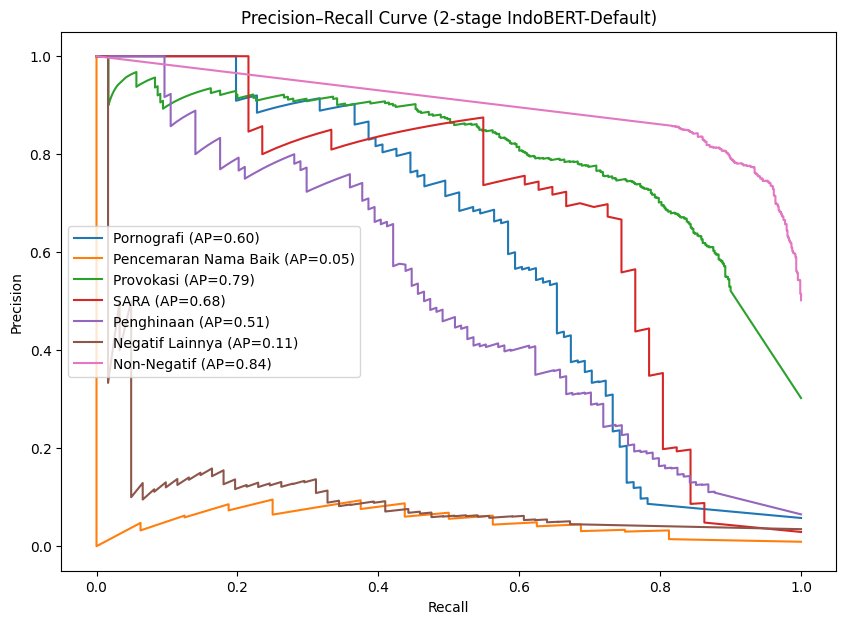

In [75]:
num_classes = 7
y_true_bin = label_binarize(test_df["label_id"], classes=list(range(num_classes)))
plt.figure(figsize=(10, 7))

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i],
        y_probs[:, i]
    )
    ap = average_precision_score(y_true_bin[:, i], y_probs[:, i])
    plt.plot(recall, precision, label=f"{all_labels[i]} (AP={ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (2-stage IndoBERT-Default)")
plt.legend()
plt.show()

### Confusion Matrix

In [39]:
stage2_confmatrix = test_df[test_df['label_stage2']!=-1]
print(stage2_confmatrix['label_stage2'].value_counts())

label_stage2
2    530
4    114
0    101
5     61
3     51
1     16
Name: count, dtype: int64


In [40]:
stage2_confmatrix.info()

<class 'pandas.core.frame.DataFrame'>
Index: 873 entries, 7219 to 17485
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Comments         873 non-null    object
 1   Final Label      873 non-null    object
 2   clean_text       873 non-null    object
 3   normalized_text  873 non-null    object
 4   label_id         873 non-null    int64 
 5   label_stage1     873 non-null    int64 
 6   label_stage2     873 non-null    int64 
dtypes: int64(3), object(4)
memory usage: 54.6+ KB


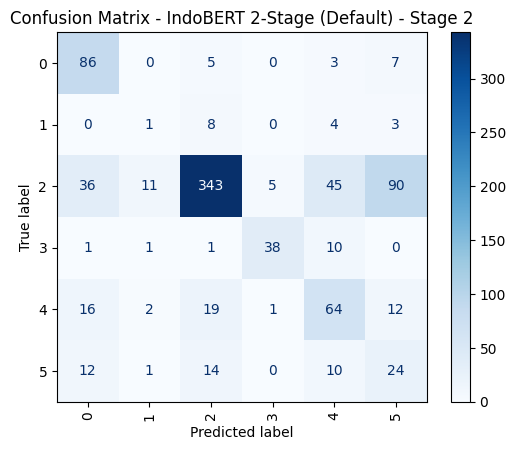

In [87]:
disp = ConfusionMatrixDisplay.from_predictions(
    stage2_confmatrix['label_stage2'],
    y_pred_s2,
    cmap='Blues',
    values_format='d'
)

plt.title("Confusion Matrix - IndoBERT 2-Stage (Default) - Stage 2")
plt.xticks(rotation=90)
plt.show()

## IndoBERT 2-Stage Tuned

In [110]:
epochs = 10
steps_per_epoch = len(train_ds_s1)
num_train_steps = steps_per_epoch * epochs
num_warmup_steps = int(0.1 * num_train_steps)

optimizer_s1, lr_schedule_s1 = create_optimizer(
    init_lr=5e-5,
    num_train_steps=num_train_steps,
    num_warmup_steps=num_warmup_steps
)

In [111]:
epochs = 10
steps_per_epoch = len(train_ds_s2)
num_train_steps = steps_per_epoch * epochs
num_warmup_steps = int(0.1 * num_train_steps)

optimizer_s2, lr_schedule_s2 = create_optimizer(
    init_lr=5e-5,
    num_train_steps=num_train_steps,
    num_warmup_steps=num_warmup_steps
)

In [112]:
model_stage1 = TFBertForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p2",
    num_labels=2
)

model_stage1.compile(
    optimizer=optimizer_s1,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p2 and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [113]:
model_stage2 = TFBertForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p2", num_labels=len(toxic_labels)
)
model_stage2.compile(
    optimizer=optimizer_s2,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p2 and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [114]:
history_s1 = model_stage1.fit(
    train_ds_s1,
    validation_data=val_ds_s1,
    epochs=epochs,
    callbacks=[early_stopping],
    class_weight=class_weights_s1
)

Epoch 1/10
1021/1021 [==============================] - 494s 440ms/step - loss: 0.4282 - accuracy: 0.8021 - val_loss: 0.4295 - val_accuracy: 0.8099
Epoch 2/10
1021/1021 [==============================] - 443s 434ms/step - loss: 0.3009 - accuracy: 0.8782 - val_loss: 0.4452 - val_accuracy: 0.8362
Epoch 3/10
1021/1021 [==============================] - 443s 434ms/step - loss: 0.1946 - accuracy: 0.9254 - val_loss: 0.4202 - val_accuracy: 0.8482
Epoch 4/10
1021/1021 [==============================] - 443s 434ms/step - loss: 0.1270 - accuracy: 0.9543 - val_loss: 0.4639 - val_accuracy: 0.8385
Epoch 5/10
1021/1021 [==============================] - 443s 434ms/step - loss: 0.0912 - accuracy: 0.9691 - val_loss: 0.6530 - val_accuracy: 0.8316
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 3.


In [115]:
history_s2 = model_stage2.fit(
    train_ds_s2,
    validation_data=val_ds_s2,
    epochs=epochs,
    callbacks=[early_stopping],
    class_weight = class_weights_s2
)

Epoch 1/10
582/582 [==============================] - 303s 441ms/step - loss: 1.3609 - accuracy: 0.4871 - val_loss: 0.9969 - val_accuracy: 0.6254
Epoch 2/10
582/582 [==============================] - 252s 433ms/step - loss: 0.9279 - accuracy: 0.6580 - val_loss: 1.2058 - val_accuracy: 0.5968
Epoch 3/10
582/582 [==============================] - 252s 432ms/step - loss: 0.5686 - accuracy: 0.7789 - val_loss: 0.9203 - val_accuracy: 0.6804
Epoch 4/10
582/582 [==============================] - 251s 431ms/step - loss: 0.3184 - accuracy: 0.8582 - val_loss: 0.9764 - val_accuracy: 0.7125
Epoch 5/10
582/582 [==============================] - 251s 432ms/step - loss: 0.2020 - accuracy: 0.9146 - val_loss: 0.9085 - val_accuracy: 0.7434
Epoch 6/10
582/582 [==============================] - 251s 432ms/step - loss: 0.1399 - accuracy: 0.9371 - val_loss: 1.0623 - val_accuracy: 0.7102
Epoch 7/10
582/582 [==============================] - 251s 431ms/step - loss: 0.1381 - accuracy: 0.9421 - val_loss: 1.0651 -

#### 2-Stage Model Evaluation (Tuned)

In [31]:
batch_sizes = [16, 32, 64, 128, 256]
texts = test_df["clean_text"].tolist()

for bs in batch_sizes:
    start = time.time()
    _ = predict_pipeline(texts[:500], model_stage1, model_stage2, batch_size=bs)
    elapsed = time.time() - start
    print(f"Batch size {bs}: {elapsed:.2f}s")

Batch size 16: 47.01s
Batch size 32: 45.79s
Batch size 64: 45.73s
Batch size 128: 45.77s
Batch size 256: 45.89s


In [116]:
# Stage 1
y_pred_s1 = tf.argmax(model_stage1.predict(test_ds_s1).logits, axis=1).numpy()
print("Stage 1 Report:\n", classification_report(y_test_s1, y_pred_s1, target_names=["Non Toxic", "Toxic"]))

# Stage 2
y_pred_s2 = tf.argmax(model_stage2.predict(test_ds_s2).logits, axis=1).numpy()
print("Stage 2 Report:\n", classification_report(y_test_s2, y_pred_s2, target_names=toxic_labels))

110/110 [==============================] - 19s 149ms/step
Stage 1 Report:
               precision    recall  f1-score   support

   Non Toxic       0.85      0.82      0.83       880
       Toxic       0.82      0.85      0.84       873

    accuracy                           0.83      1753
   macro avg       0.83      0.83      0.83      1753
weighted avg       0.83      0.83      0.83      1753

55/55 [==============================] - 11s 149ms/step
Stage 2 Report:
                       precision    recall  f1-score   support

          Pornografi       0.76      0.79      0.78       101
Pencemaran Nama Baik       0.21      0.25      0.23        16
           Provokasi       0.87      0.79      0.83       530
                SARA       0.60      0.86      0.71        51
          Penghinaan       0.60      0.61      0.61       114
     Negatif Lainnya       0.28      0.34      0.31        61

            accuracy                           0.73       873
           macro avg       

In [117]:
start_time = time.time()
final_preds = predict_pipeline(test_df["normalized_text"].tolist(), model_stage1, model_stage2)

print("Combined 2-Stage Classification Report:\n")
print(classification_report(
    test_df["label_id"],
    final_preds,
    target_names=all_labels,
    zero_division=0
))
end_time = time.time()

total_time = end_time - start_time
num_samples = len(test_df)

print(f"Total inference time: {total_time:.4f} seconds")
print(f"Average time per sample: {total_time / num_samples:.6f} seconds")
print(f"Samples per second: {num_samples / total_time:.2f}")

Combined 2-Stage Classification Report:

                      precision    recall  f1-score   support

          Pornografi       0.70      0.56      0.62       101
Pencemaran Nama Baik       0.19      0.25      0.22        16
           Provokasi       0.74      0.72      0.73       530
                SARA       0.51      0.80      0.63        51
          Penghinaan       0.52      0.57      0.55       114
     Negatif Lainnya       0.17      0.23      0.20        61
         Non-Negatif       0.85      0.82      0.83       880

            accuracy                           0.73      1753
           macro avg       0.53      0.56      0.54      1753
        weighted avg       0.74      0.73      0.74      1753

Total inference time: 189.1817 seconds
Average time per sample: 0.107919 seconds
Samples per second: 9.27


In [118]:
y_pred, y_probs = predict_pipeline_full(test_df["normalized_text"].tolist(), model_stage1, model_stage2)
print("Combined 2-Stage Classification Report:\n")
print(classification_report(test_df["label_id"], y_pred, target_names=all_labels))

Combined 2-Stage Classification Report:

                      precision    recall  f1-score   support

          Pornografi       0.70      0.56      0.62       101
Pencemaran Nama Baik       0.19      0.25      0.22        16
           Provokasi       0.74      0.72      0.73       530
                SARA       0.51      0.80      0.63        51
          Penghinaan       0.52      0.57      0.55       114
     Negatif Lainnya       0.17      0.23      0.20        61
         Non-Negatif       0.85      0.82      0.83       880

            accuracy                           0.73      1753
           macro avg       0.53      0.56      0.54      1753
        weighted avg       0.74      0.73      0.74      1753



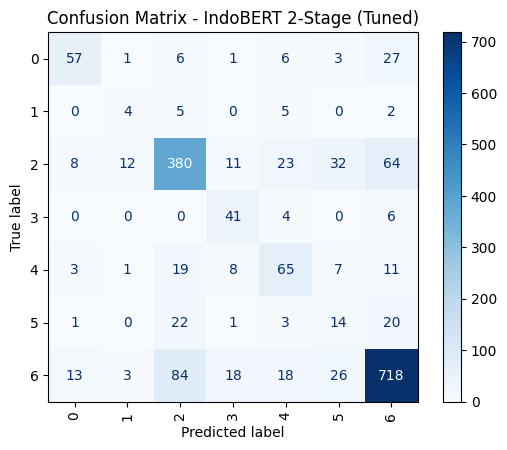

In [119]:
disp = ConfusionMatrixDisplay.from_predictions(
    test_df['label_id'],
    y_pred,
    cmap='Blues',
    values_format='d'
)

plt.title("Confusion Matrix - IndoBERT 2-Stage (Tuned)")
plt.xticks(rotation=90)
plt.show()

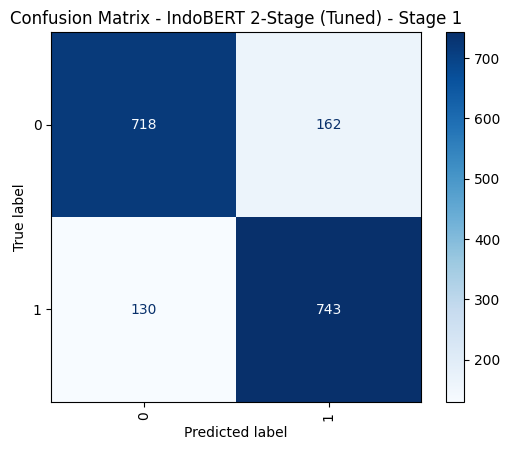

In [120]:
disp = ConfusionMatrixDisplay.from_predictions(
    test_df['label_stage1'],
    y_pred_s1,
    cmap='Blues',
    values_format='d'
)

plt.title("Confusion Matrix - IndoBERT 2-Stage (Tuned) - Stage 1")
plt.xticks(rotation=90)
plt.show()

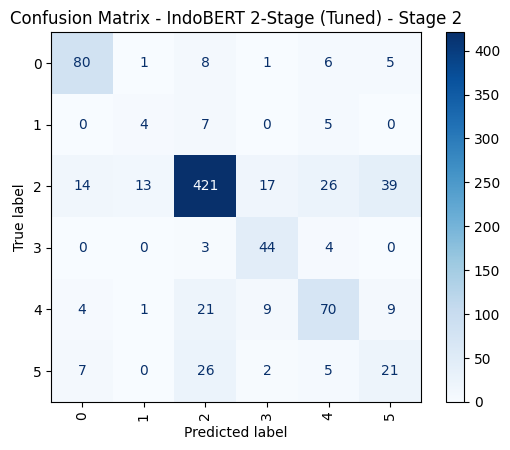

In [121]:
disp = ConfusionMatrixDisplay.from_predictions(
    stage2_confmatrix['label_stage2'],
    y_pred_s2,
    cmap='Blues',
    values_format='d'
)

plt.title("Confusion Matrix - IndoBERT 2-Stage (Tuned) - Stage 2")
plt.xticks(rotation=90)
plt.show()

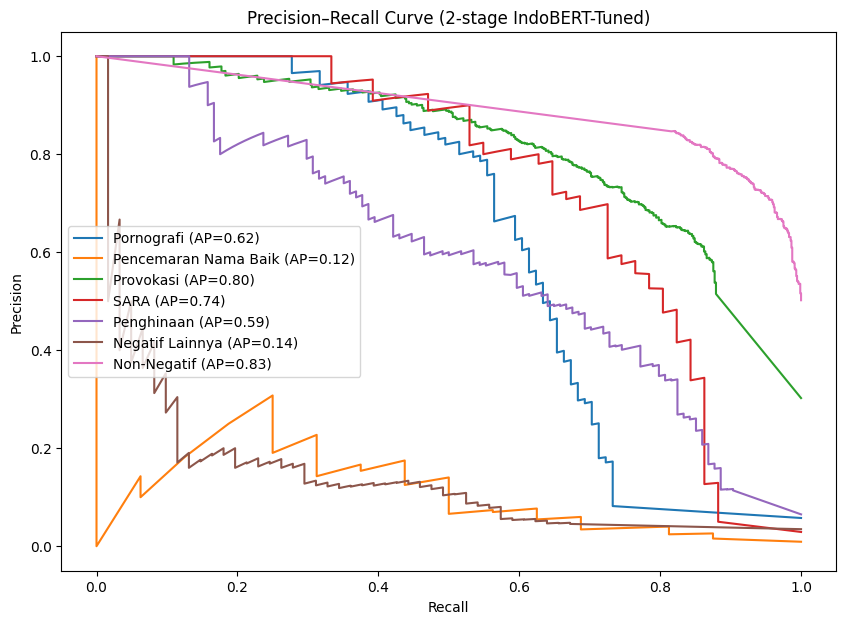

In [122]:
num_classes = 7
y_true_bin = label_binarize(test_df["label_id"], classes=list(range(num_classes)))
plt.figure(figsize=(10, 7))

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i],
        y_probs[:, i]
    )
    ap = average_precision_score(y_true_bin[:, i], y_probs[:, i])
    plt.plot(recall, precision, label=f"{all_labels[i]} (AP={ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (2-stage IndoBERT-Tuned)")
plt.legend()
plt.show()

## IndoBERT 1-Stage Default

#### Data Splitting

In [32]:
# Splitting and creating datasets
train_texts_1stage, y_train_1stage = combined_df["normalized_text"].tolist(), combined_df["label_id"].values
val_texts_1stage, y_val_1stage = val_df["normalized_text"].tolist(), val_df["label_id"].values
test_texts_1stage, y_test_1stage = test_df["normalized_text"].tolist(), test_df["label_id"].values

print(f"\nBERT 1-stage - Train: {len(y_train_1stage)}, Val: {len(y_val_1stage)}, Test: {len(y_test_1stage)}")


BERT 1-stage - Train: 16334, Val: 1752, Test: 1753


In [33]:
slice1 = test_df[test_df['augmented']==True]
print(f"{len(slice1)}")

0


In [34]:
enc_train_1stage, enc_val_1stage, enc_test_1stage = tokenize(train_texts_1stage), tokenize(val_texts_1stage), tokenize(test_texts_1stage)

batch_size = 16

# Stage 1
train_ds_1stage = tf.data.Dataset.from_tensor_slices((dict(enc_train_1stage), y_train_1stage.astype('int32'))).shuffle(len(y_train_1stage)).batch(batch_size)
val_ds_1stage = tf.data.Dataset.from_tensor_slices((dict(enc_val_1stage), y_val_1stage.astype('int32'))).batch(batch_size)
test_ds_1stage  = tf.data.Dataset.from_tensor_slices((dict(enc_test_1stage), y_test_1stage.astype('int32'))).batch(batch_size)

weights_1stage = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_1stage),
    y=y_train_1stage
)

class_weights_1stage = {i: weights_1stage[i] for i in range(len(weights_1stage))}

print("Calculated Class Weights\n")
print(class_weights_1stage)

Calculated Class Weights

{0: np.float64(1.578774405567369), 1: np.float64(9.44707923655292), 2: np.float64(0.5500774567252643), 3: np.float64(2.9839240043843622), 4: np.float64(1.4082248469695664), 5: np.float64(2.61595131326073), 6: np.float64(0.33164135466580036)}


In [126]:
model_1stage_default = TFBertForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p2",
    num_labels=7
)

optimizer = tf.keras.optimizers.AdamW(
    learning_rate=2e-5,
    epsilon=1e-8,
    weight_decay=0.01
)

model_1stage_default.compile(
    optimizer=optimizer,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p2 and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [127]:
epochs=10

In [47]:
history_1stage_default = model_1stage_default.fit(
    train_ds_1stage,
    validation_data=val_ds_1stage,
    epochs=epochs,
    callbacks=[early_stopping],
    class_weight = class_weights_1stage
)

Epoch 1/5
877/877 [==============================] - 449s 459ms/step - loss: 1.3606 - accuracy: 0.4980 - val_loss: 1.2312 - val_accuracy: 0.5845
Epoch 2/5
877/877 [==============================] - 398s 453ms/step - loss: 0.9026 - accuracy: 0.6432 - val_loss: 1.1491 - val_accuracy: 0.6130
Epoch 3/5
877/877 [==============================] - 397s 453ms/step - loss: 0.5939 - accuracy: 0.7419 - val_loss: 0.9915 - val_accuracy: 0.6244
Epoch 4/5
877/877 [==============================] - 397s 453ms/step - loss: 0.4208 - accuracy: 0.7999 - val_loss: 1.0979 - val_accuracy: 0.6804
Epoch 5/5
877/877 [==============================] - 397s 453ms/step - loss: 0.3576 - accuracy: 0.8327 - val_loss: 1.1513 - val_accuracy: 0.6752
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 3.


#### Classification Report

In [48]:
# Prediction Results
y_pred_1stage_default = tf.argmax(model_1stage_default.predict(test_ds_1stage).logits, axis=1).numpy()
print("1-stage BERT Report:\n", classification_report(y_test_1stage, y_pred_1stage_default, target_names=all_labels))

110/110 [==============================] - 19s 149ms/step
1-stage BERT Report:
                       precision    recall  f1-score   support

          Pornografi       0.28      0.75      0.41       101
Pencemaran Nama Baik       0.04      0.06      0.05        16
           Provokasi       0.78      0.67      0.72       530
                SARA       0.49      0.84      0.62        51
          Penghinaan       0.36      0.57      0.44       114
     Negatif Lainnya       0.20      0.20      0.20        61
         Non-Negatif       0.86      0.66      0.75       880

            accuracy                           0.64      1753
           macro avg       0.43      0.54      0.45      1753
        weighted avg       0.73      0.64      0.67      1753



#### AUC PR-Curve

In [49]:
# 1. Get logits
outputs_default = model_1stage_default.predict(test_ds_1stage)
logits_default = outputs_default.logits

# 2. Convert to probabilities
probs_default = tf.nn.softmax(logits_default, axis=1).numpy()

# 3. Extract true labels from dataset
y_true_default = []
for _, labels in test_ds_1stage:
    y_true_default.append(labels.numpy())
y_true_default = np.concatenate(y_true_default)

110/110 [==============================] - 16s 149ms/step


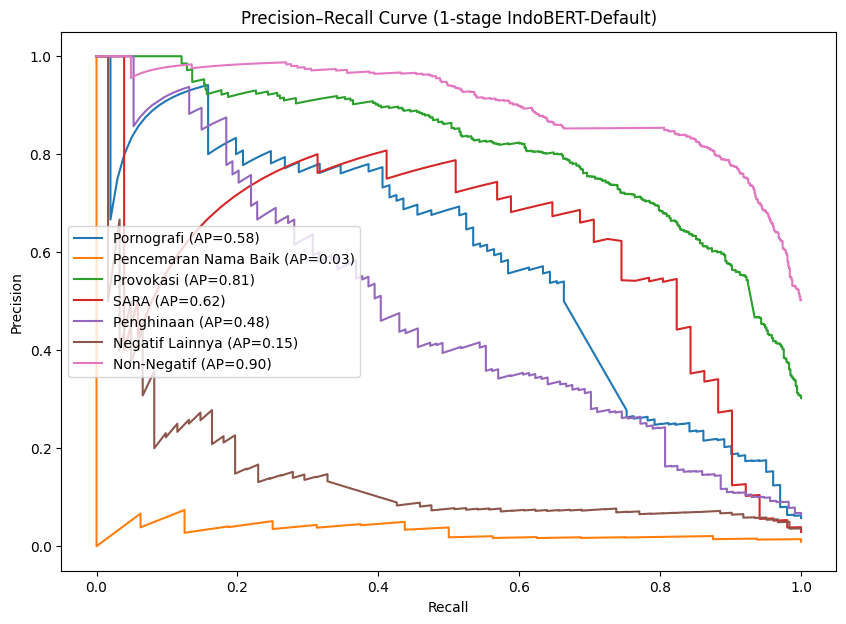

In [56]:
num_classes = 7
y_true_bin = label_binarize(y_true_default, classes=list(range(num_classes)))
plt.figure(figsize=(10, 7))

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i],
        probs_default[:, i]
    )
    ap = average_precision_score(y_true_bin[:, i], probs_default[:, i])
    plt.plot(recall, precision, label=f"{all_labels[i]} (AP={ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (1-stage IndoBERT-Default)")
plt.legend()
plt.show()

#### Confusion Matrix

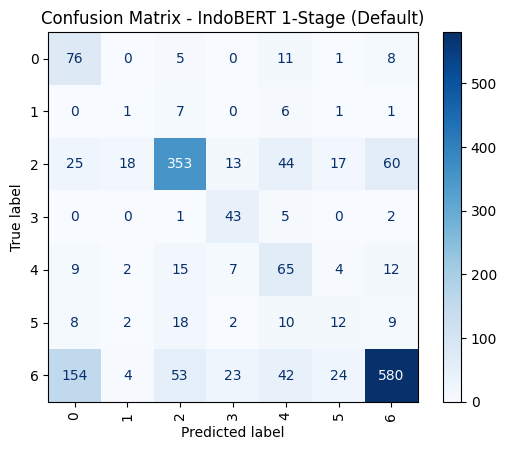

In [52]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test_1stage,
    y_pred_1stage_default,
    cmap='Blues',
    values_format='d'
)

plt.title("Confusion Matrix - IndoBERT 1-Stage (Default)")
plt.xticks(rotation=90)
plt.show()

### Inference Time

In [55]:
start_time = time.time()

y_pred_1stage_default = tf.argmax(model_1stage_default.predict(test_ds_1stage).logits, axis=1).numpy()

end_time = time.time()

total_time = end_time - start_time
num_samples = len(test_df)

print(f"Total inference time: {total_time:.4f} seconds")
print(f"Average time per sample: {total_time / num_samples:.6f} seconds")
print(f"Samples per second: {num_samples / total_time:.2f}")

110/110 [==============================] - 16s 146ms/step
Total inference time: 16.1987 seconds
Average time per sample: 0.009241 seconds
Samples per second: 108.22


## IndoBERT 1-Stage Tuned

In [35]:
epochs = 10
batch_size = 16
steps_per_epoch = len(train_ds_1stage)
num_train_steps = steps_per_epoch * epochs
num_warmup_steps = int(0.1 * num_train_steps)

optimizer_1stage, lr_schedule_1stage = create_optimizer(
    init_lr=2e-5,
    num_train_steps=num_train_steps,
    num_warmup_steps=num_warmup_steps
)

model_1stage = TFBertForSequenceClassification.from_pretrained(
    "indobenchmark/indobert-base-p2",
    num_labels=7
)

model_1stage.compile(
    optimizer=optimizer_1stage,
    loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=['accuracy']
)

tf_model.h5:   0%|          | 0.00/656M [00:00<?, ?B/s]

TensorFlow and JAX classes are deprecated and will be removed in Transformers v5. We recommend migrating to PyTorch classes or pinning your version of Transformers.
All model checkpoint layers were used when initializing TFBertForSequenceClassification.

Some layers of TFBertForSequenceClassification were not initialized from the model checkpoint at indobenchmark/indobert-base-p2 and are newly initialized: ['classifier']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [39]:
history_1stage = model_1stage.fit(
    train_ds_1stage,
    validation_data=val_ds_1stage,
    epochs=epochs,
    callbacks=[early_stopping],
    class_weight = class_weights_1stage
)

Epoch 1/10


I0000 00:00:1771165208.772841      94 service.cc:152] XLA service 0x7925b9d86660 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1771165208.772886      94 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1771165208.772890      94 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1771165208.948747      94 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1771165209.221761      94 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


1021/1021 [==============================] - 502s 443ms/step - loss: 1.4942 - accuracy: 0.4711 - val_loss: 1.0661 - val_accuracy: 0.6581
Epoch 2/10
1021/1021 [==============================] - 446s 437ms/step - loss: 0.9688 - accuracy: 0.6788 - val_loss: 0.9597 - val_accuracy: 0.6735
Epoch 3/10
1021/1021 [==============================] - 446s 437ms/step - loss: 0.5921 - accuracy: 0.7830 - val_loss: 0.9065 - val_accuracy: 0.7032
Epoch 4/10
1021/1021 [==============================] - 445s 436ms/step - loss: 0.3663 - accuracy: 0.8521 - val_loss: 0.9912 - val_accuracy: 0.7061
Epoch 5/10
1021/1021 [==============================] - 445s 436ms/step - loss: 0.2460 - accuracy: 0.8990 - val_loss: 0.9854 - val_accuracy: 0.7226
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 3.


#### Classification Report & Inference Time

In [40]:
# Prediction Results
start_time = time.time()

y_pred_1stage = tf.argmax(model_1stage.predict(test_ds_1stage).logits, axis=1).numpy()

end_time = time.time()

total_time = end_time - start_time
num_samples = len(test_df)

print(f"Total inference time: {total_time:.4f} seconds")
print(f"Average time per sample: {total_time / num_samples:.6f} seconds")
print(f"Samples per second: {num_samples / total_time:.2f}")
print("1-stage BERT Report:\n", classification_report(y_test_1stage, y_pred_1stage, target_names=all_labels))

110/110 [==============================] - 16s 150ms/step
Total inference time: 16.5286 seconds
Average time per sample: 0.009429 seconds
Samples per second: 106.06
1-stage BERT Report:
                       precision    recall  f1-score   support

          Pornografi       0.53      0.75      0.62       101
Pencemaran Nama Baik       0.16      0.38      0.23        16
           Provokasi       0.74      0.72      0.73       530
                SARA       0.64      0.84      0.73        51
          Penghinaan       0.46      0.65      0.54       114
     Negatif Lainnya       0.21      0.26      0.24        61
         Non-Negatif       0.89      0.76      0.82       880

            accuracy                           0.72      1753
           macro avg       0.52      0.62      0.56      1753
        weighted avg       0.76      0.72      0.73      1753



#### AUC PR-Curve

In [41]:
# 1. Get logits
outputs = model_1stage.predict(test_ds_1stage)
logits = outputs.logits

# 2. Convert to probabilities
probs = tf.nn.softmax(logits, axis=1).numpy()

# 3. Extract true labels from dataset
y_true = []
for _, labels in test_ds_1stage:
    y_true.append(labels.numpy())
y_true = np.concatenate(y_true)


110/110 [==============================] - 16s 150ms/step


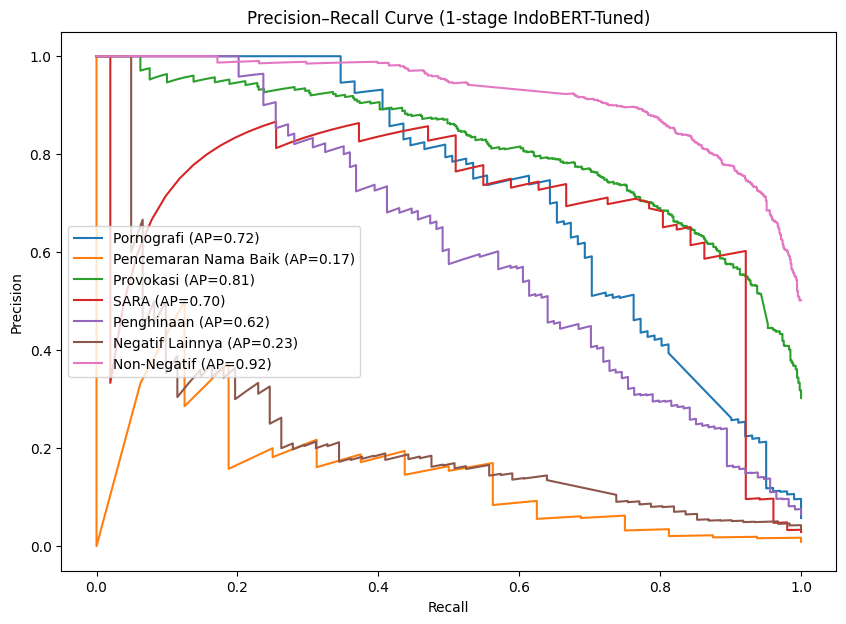

In [42]:
num_classes = 7
y_true_bin = label_binarize(y_true, classes=list(range(num_classes)))
plt.figure(figsize=(10, 7))

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i],
        probs[:, i]
    )
    ap = average_precision_score(y_true_bin[:, i], probs[:, i])
    plt.plot(recall, precision, label=f"{all_labels[i]} (AP={ap:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall Curve (1-stage IndoBERT-Tuned)")
plt.legend()
plt.show()

#### Confusion Matrix

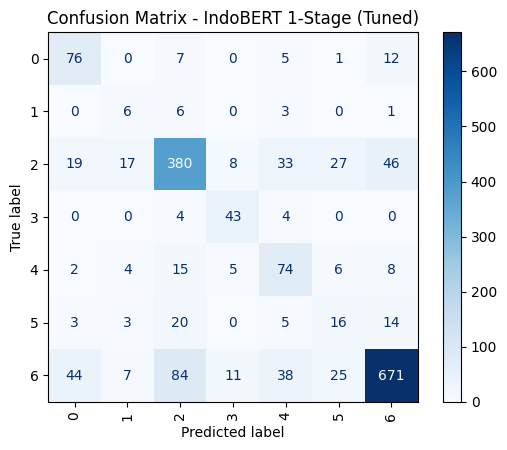

In [43]:
disp = ConfusionMatrixDisplay.from_predictions(
    y_test_1stage,
    y_pred_1stage,
    cmap='Blues',
    values_format='d'
)

plt.title("Confusion Matrix - IndoBERT 1-Stage (Tuned)")
plt.xticks(rotation=90)
plt.show()

#### Saving best model 

In [48]:
model_1stage.save_pretrained("/kaggle/working/indobert_1stage_normalized")
tokenizer.save_pretrained("/kaggle/working/tokenizer_1stage_normalized")

('/kaggle/working/tokenizer_1stage_normalized/tokenizer_config.json',
 '/kaggle/working/tokenizer_1stage_normalized/special_tokens_map.json',
 '/kaggle/working/tokenizer_1stage_normalized/vocab.txt',
 '/kaggle/working/tokenizer_1stage_normalized/added_tokens.json',
 '/kaggle/working/tokenizer_1stage_normalized/tokenizer.json')